# Inaugural Address Sentiment Analysis

This notebook analyzes five inaugural addresses using two sentiment methods and creates word clouds for each speech.

## Before you run
Replace the placeholder text in the input cell with the speech texts for Jefferson, Lincoln, Wilson, Truman, and Reagan.

In [5]:
!pip -q install pandas numpy matplotlib seaborn nltk textblob wordcloud vaderSentiment

In [6]:
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('vader_lexicon', quiet=True)

analyzer = SentimentIntensityAnalyzer()
plt.rcParams['figure.dpi'] = 130
plt.rcParams['axes.titlesize'] = 12

In [7]:
speeches = {
    'Jefferson': {
        'year': 1801,
        'text': ''
    },
    'Lincoln': {
        'year': 1861,
        'text': ''
    },
    'Wilson': {
        'year': 1913,
        'text': ''
    },
    'Truman': {
        'year': 1949,
        'text': ''
    },
    'Reagan': {
        'year': 1981,
        'text': ''
    },
}

speeches['Jefferson']['text'] = Path('speeches/jefferson.txt').read_text(encoding='utf-8')
speeches['Lincoln']['text'] = Path('speeches/lincoln.txt').read_text(encoding='utf-8')
speeches['Wilson']['text'] = Path('speeches/wilson.txt').read_text(encoding='utf-8')
speeches['Truman']['text'] = Path('speeches/truman.txt').read_text(encoding='utf-8')
speeches['Reagan']['text'] = Path('speeches/reagan.txt').read_text(encoding='utf-8')

In [8]:
def clean_text(text: str) -> str:
    text = str(text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

rows = []
missing = []

for president, info in speeches.items():
    text = clean_text(info['text'])
    if not text or 'PASTE ' in text:
        missing.append(president)
    rows.append({'President': president, 'Year': info['year'], 'Text': text})

df = pd.DataFrame(rows)

if missing:
    print('Warning: these speeches still have placeholder text:', ', '.join(missing))

df

,President,Year,Text
0,Jefferson,1801,"FRIENDS AND FELLOW-CITIZENS, Called upon to un..."
1,Lincoln,1861,Fellow citizens of the United States: In compl...
2,Wilson,1913,There has been a change of government. It bega...
3,Truman,1949,"Mr. Vice President, Mr. Chief Justice, fellow ..."
4,Reagan,1981,"Senator Hatfield, Mr. Chief Justice, Mr. Presi..."


#2) Sentiment analysis using two methods
vader: rule-based sentiment analyzer
textblob: lexicon-based polarity score

In [9]:
def vader_sentiment(text: str) -> float:
    return analyzer.polarity_scores(text)['compound']

def textblob_sentiment(text: str) -> float:
    return TextBlob(text).sentiment.polarity

df['VADER'] = df['Text'].apply(vader_sentiment)
df['TextBlob'] = df['Text'].apply(textblob_sentiment)
df[['President', 'Year', 'VADER', 'TextBlob']]

,President,Year,VADER,TextBlob
0,Jefferson,1801,0.9999,0.235479
1,Lincoln,1861,0.9993,0.133248
2,Wilson,1913,0.9993,0.156416
3,Truman,1949,1.0000,0.184817
4,Reagan,1981,0.9999,0.183641


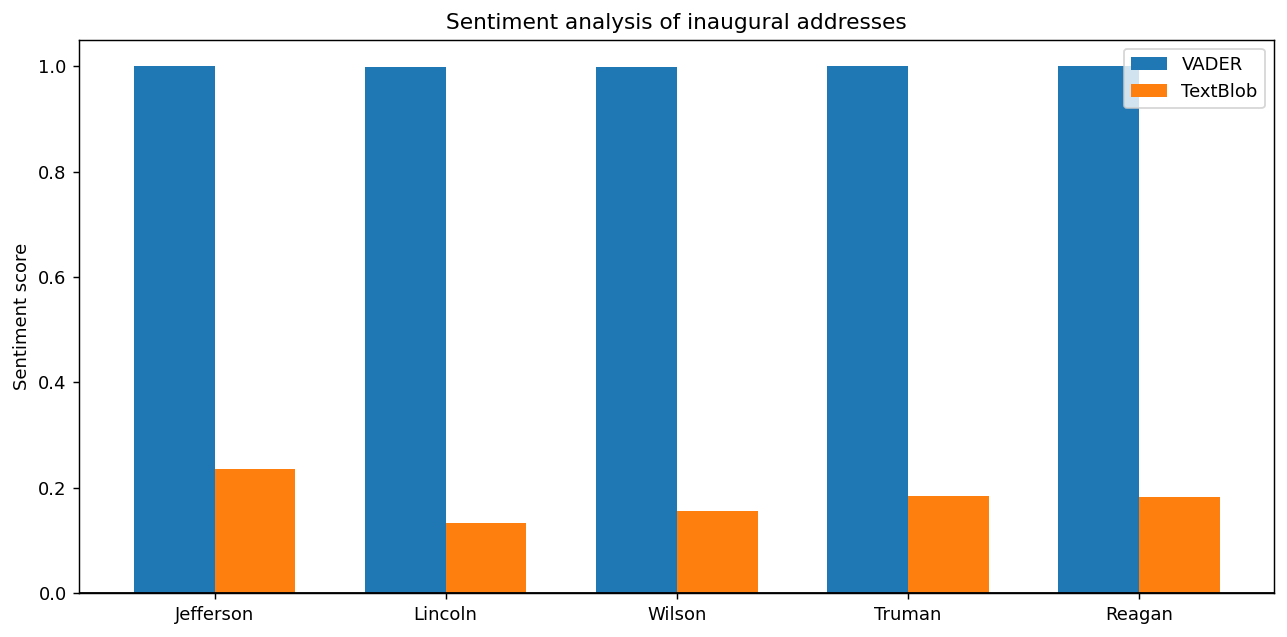

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(df))
width = 0.35

ax.bar([i - width/2 for i in x], df['VADER'], width=width, label='VADER')
ax.bar([i + width/2 for i in x], df['TextBlob'], width=width, label='TextBlob')
ax.axhline(0, color='black', linewidth=1)
ax.set_xticks(list(x))
ax.set_xticklabels(df['President'])
ax.set_ylabel('Sentiment score')
ax.set_title('Sentiment analysis of inaugural addresses')
ax.legend()
plt.tight_layout()
plt.show()

#Word clouds

This creates one word cloud per president and saves each image.

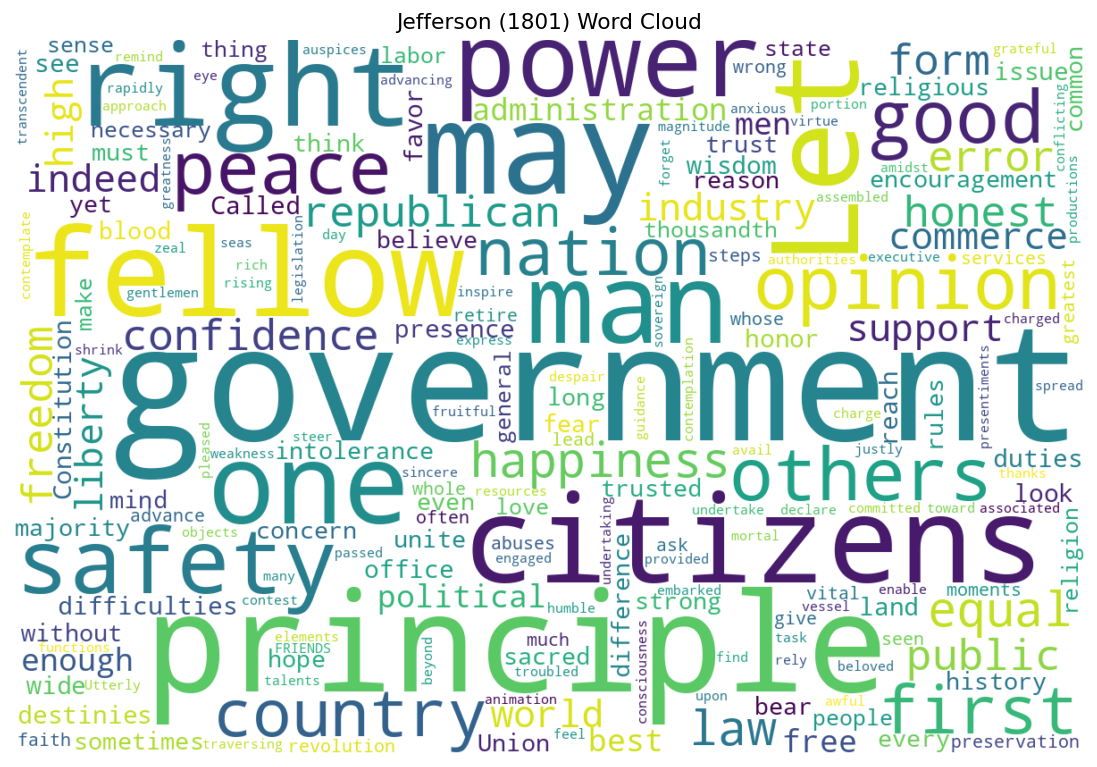

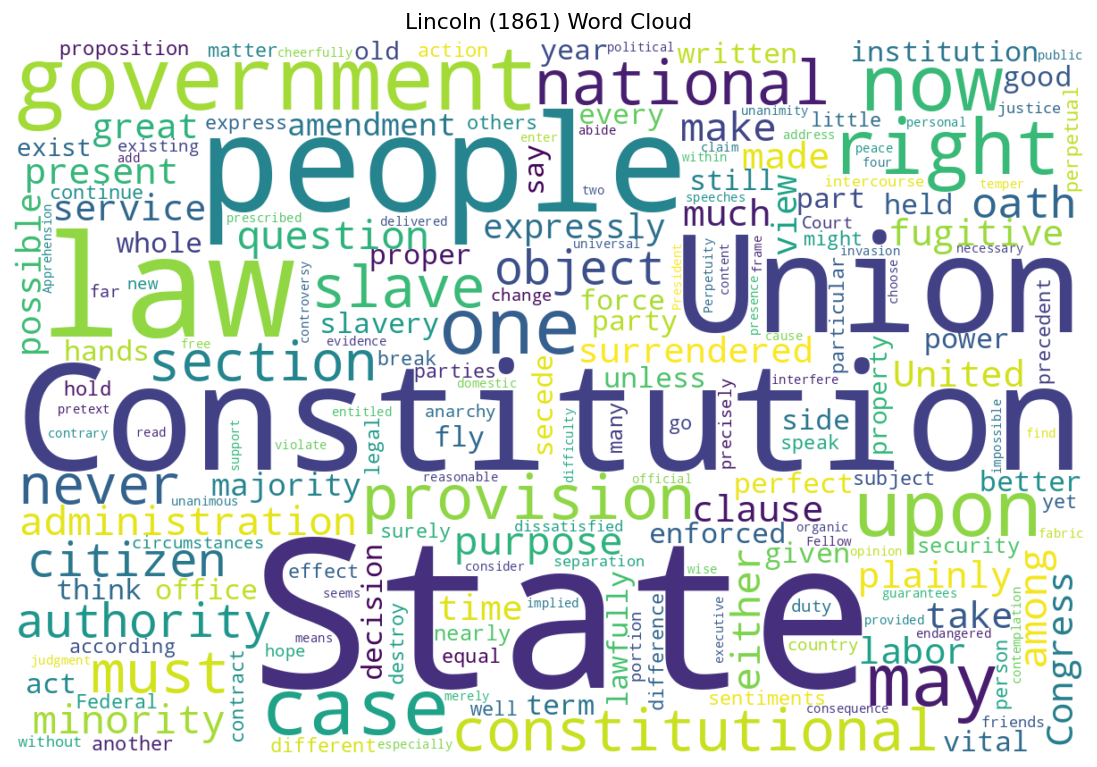

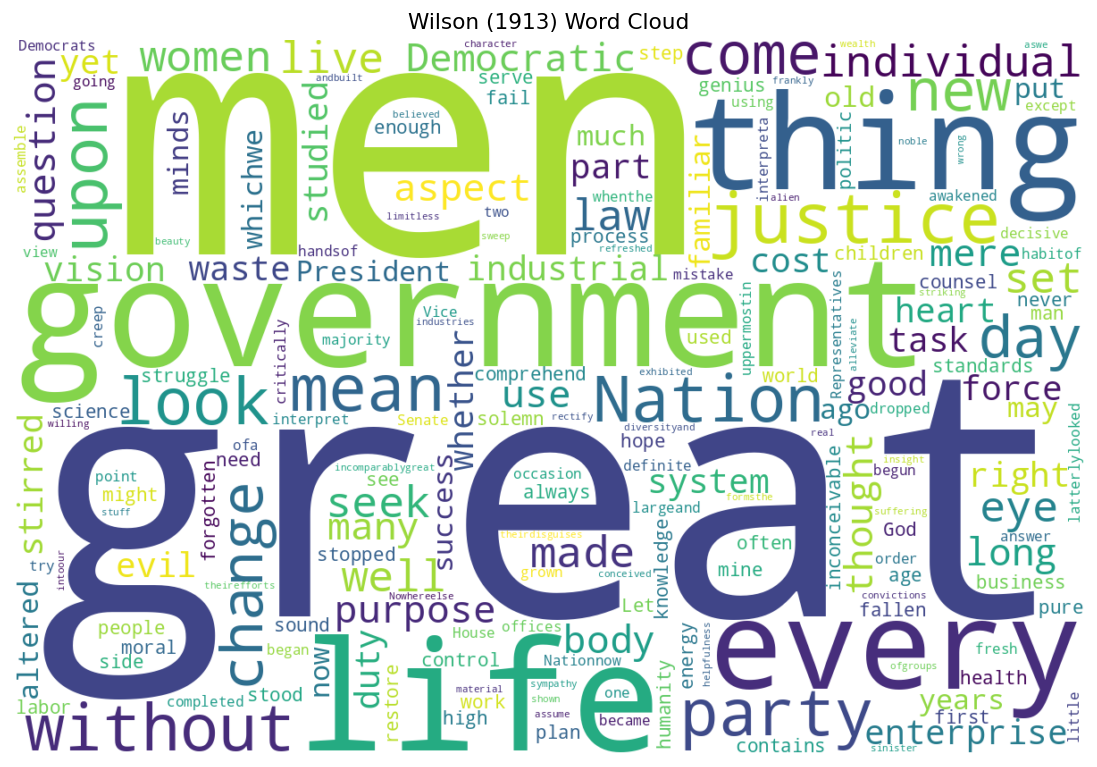

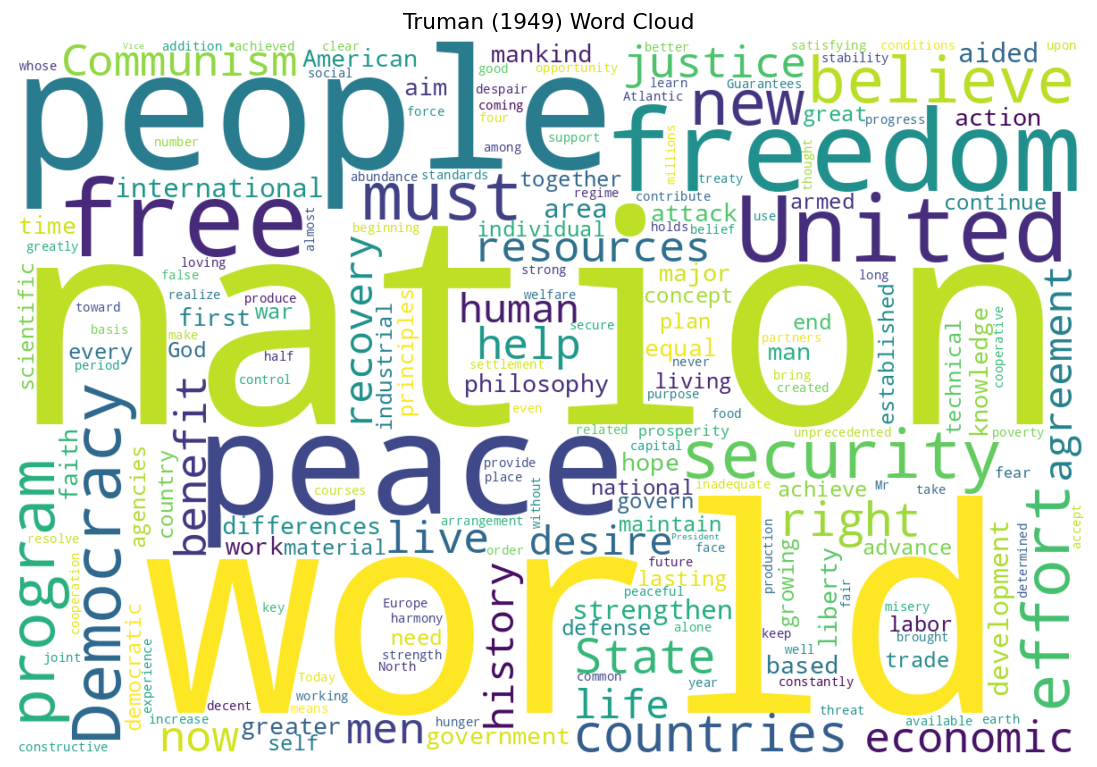

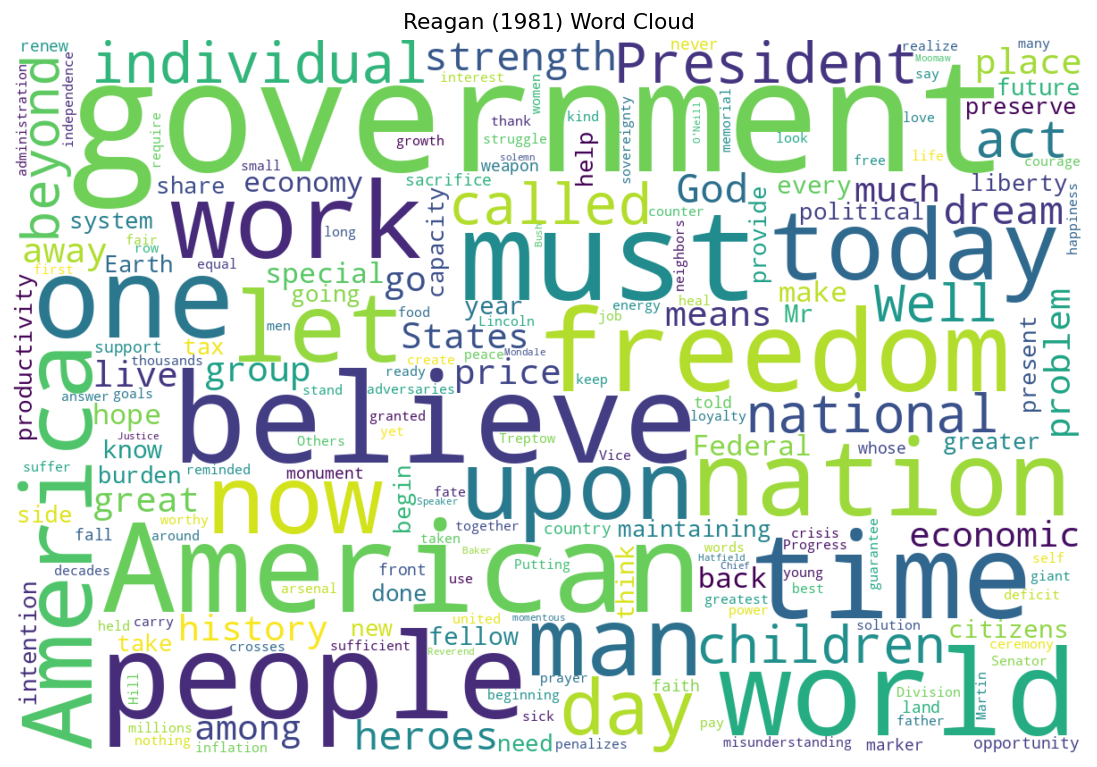

In [11]:
output_dir = Path('inaugural_wordclouds')
output_dir.mkdir(exist_ok=True)

custom_stopwords = set(STOPWORDS)
custom_stopwords.update({
    'the', 'and', 'to', 'of', 'in', 'that', 'we', 'our', 'be', 'is', 'it',
    'for', 'a', 'by', 'as', 'with', 'this', 'have', 'are', 'will', 'not',
    'from', 'or', 'which', 'their', 'they', 'i', 'you', 'your', 'us'
})

def make_wordcloud(text: str, title: str, outpath: Path):
    wc = WordCloud(
        width=1200,
        height=800,
        background_color='white',
        stopwords=custom_stopwords,
        collocations=False
    ).generate(text)

    plt.figure(figsize=(10, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.tight_layout()
    plt.savefig(outpath, dpi=200, bbox_inches='tight')
    plt.show()

for _, row in df.iterrows():
    make_wordcloud(
        row['Text'],
        f"{row['President']} ({row['Year']}) Word Cloud",
        output_dir / f"{row['President'].lower()}_{row['Year']}.png"
    )

#Save results

In [12]:
df.to_csv('inaugural_address_sentiment_results.csv', index=False)
df

,President,Year,Text,VADER,TextBlob
0,Jefferson,1801,"FRIENDS AND FELLOW-CITIZENS, Called upon to un...",0.9999,0.235479
1,Lincoln,1861,Fellow citizens of the United States: In compl...,0.9993,0.133248
2,Wilson,1913,There has been a change of government. It bega...,0.9993,0.156416
3,Truman,1949,"Mr. Vice President, Mr. Chief Justice, fellow ...",1.0000,0.184817
4,Reagan,1981,"Senator Hatfield, Mr. Chief Justice, Mr. Presi...",0.9999,0.183641


#Quick interpretation helper

This summarizes whether the two sentiment methods agree on polarity.

In [13]:
def polarity_label(score: float, threshold: float = 0.05) -> str:
    if score > threshold:
        return 'positive'
    if score < -threshold:
        return 'negative'
    return 'neutral'

df['VADER_label'] = df['VADER'].apply(polarity_label)
df['TextBlob_label'] = df['TextBlob'].apply(polarity_label)
df['Agree'] = df['VADER_label'] == df['TextBlob_label']

display(df[['President', 'Year', 'VADER_label', 'TextBlob_label', 'Agree']])
print(f"Agreement rate: {df['Agree'].mean():.0%}")

,President,Year,VADER_label,TextBlob_label,Agree
0,Jefferson,1801,positive,positive,True
1,Lincoln,1861,positive,positive,True
2,Wilson,1913,positive,positive,True
3,Truman,1949,positive,positive,True
4,Reagan,1981,positive,positive,True


Agreement rate: 100%
